In [1]:
import os
os.listdir()


['01_qc_and_normalization.ipynb', '.ipynb_checkpoints', 'data']

In [2]:
import os
os.listdir("data")


[]

In [3]:
import os
os.getcwd()


'/Users/victoriaciszewska/rna-seq-pipeline/rna-seq-pipeline'

In [5]:
os.listdir("/Users/victoriaciszewska/rna-seq-pipeline/rna-seq-pipeline/data")


[]

In [6]:
import os
os.listdir("/Users/victoriaciszewska/rna-seq-pipeline")


['rna-seq-pipeline',
 'anaconda_projects',
 'Untitled.ipynb',
 '.virtual_documents',
 '.ipynb_checkpoints']

In [9]:
from pydeseq2.utils import load_example_data

data = load_example_data()
type(data)


pandas.core.frame.DataFrame

In [10]:
data = load_example_data()
data.head()


,gene1,gene2,gene3,gene4,gene5,gene6,gene7,gene8,gene9,gene10
sample1,12,21,4,130,18,0,16,54,49,3
sample2,1,44,2,63,11,10,70,32,57,9
sample3,4,4,11,180,21,3,28,34,65,2
sample4,1,10,2,100,44,9,28,16,33,9
sample5,1,11,6,135,16,2,32,29,31,5


In [11]:
import pandas as pd

metadata_df = pd.DataFrame({
    "condition": ["control", "control", "control", "treated", "treated"]
}, index=["sample1", "sample2", "sample3", "sample4", "sample5"])


In [13]:
from pydeseq2.utils import load_example_data
data = load_example_data()


In [14]:
data.head()


,gene1,gene2,gene3,gene4,gene5,gene6,gene7,gene8,gene9,gene10
sample1,12,21,4,130,18,0,16,54,49,3
sample2,1,44,2,63,11,10,70,32,57,9
sample3,4,4,11,180,21,3,28,34,65,2
sample4,1,10,2,100,44,9,28,16,33,9
sample5,1,11,6,135,16,2,32,29,31,5


In [15]:
counts_df = data.copy()


In [16]:
import pandas as pd

metadata_df = pd.DataFrame({
    "condition": ["control", "control", "treated", "treated", "treated"]
}, index=["sample1", "sample2", "sample3", "sample4", "sample5"])


In [17]:
counts_df.to_csv("data/counts_matrix.csv")
metadata_df.to_csv("data/sample_metadata.csv")


In [18]:
os.listdir("data")


['sample_metadata.csv', 'counts_matrix.csv']

In [19]:
import pandas as pd

counts_df = pd.read_csv("data/counts_matrix.csv", index_col=0)
metadata_df = pd.read_csv("data/sample_metadata.csv", index_col=0)

counts_df.head()
metadata_df.head()


,condition
sample1,control
sample2,control
sample3,treated
sample4,treated
sample5,treated


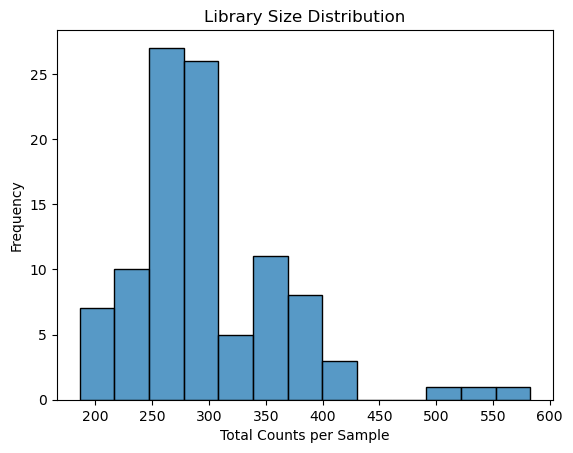

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

library_sizes = counts_df.sum(axis=1)

sns.histplot(library_sizes)
plt.title("Library Size Distribution")
plt.xlabel("Total Counts per Sample")
plt.ylabel("Frequency")
plt.show()


In [24]:
counts_df.index[:10]


Index(['sample1', 'sample2', 'sample3', 'sample4', 'sample5', 'sample6',
       'sample7', 'sample8', 'sample9', 'sample10'],
      dtype='object')

In [25]:
import pandas as pd

metadata_df = pd.DataFrame(
    {"condition": ["control"] * 50 + ["treated"] * 50},
    index=counts_df.index
)


In [26]:
metadata_df.to_csv("data/sample_metadata.csv")


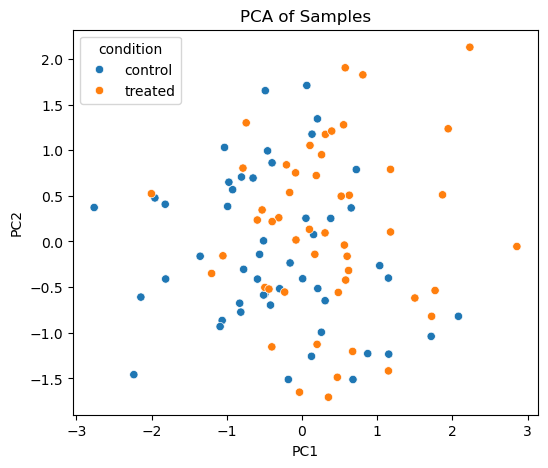

In [27]:
from sklearn.decomposition import PCA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(np.log1p(counts_df))

plt.figure(figsize=(6,5))
sns.scatterplot(
    x=pca_coords[:,0],
    y=pca_coords[:,1],
    hue=metadata_df["condition"]
)
plt.title("PCA of Samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [28]:
import pandas as pd

counts_df = pd.read_csv("data/counts_matrix.csv", index_col=0)
metadata_df = pd.read_csv("data/sample_metadata.csv", index_col=0)

counts_df.head()
metadata_df.head()


,condition
sample1,control
sample2,control
sample3,control
sample4,control
sample5,control


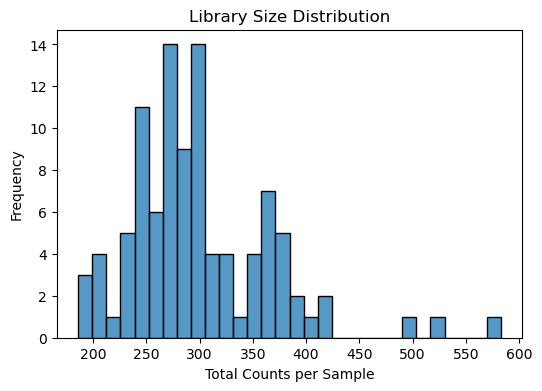

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

library_sizes = counts_df.sum(axis=1)

plt.figure(figsize=(6,4))
sns.histplot(library_sizes, bins=30)
plt.title("Library Size Distribution")
plt.xlabel("Total Counts per Sample")
plt.ylabel("Frequency")
plt.show()


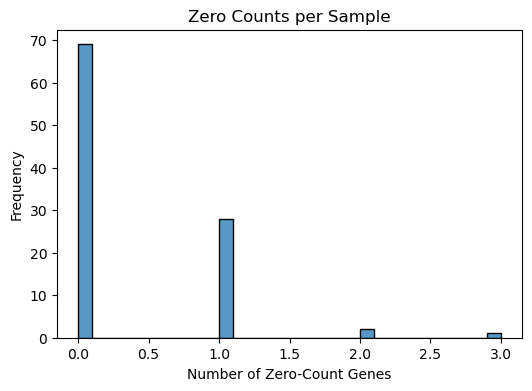

In [30]:
zero_counts = (counts_df == 0).sum(axis=1)

plt.figure(figsize=(6,4))
sns.histplot(zero_counts, bins=30)
plt.title("Zero Counts per Sample")
plt.xlabel("Number of Zero-Count Genes")
plt.ylabel("Frequency")
plt.show()


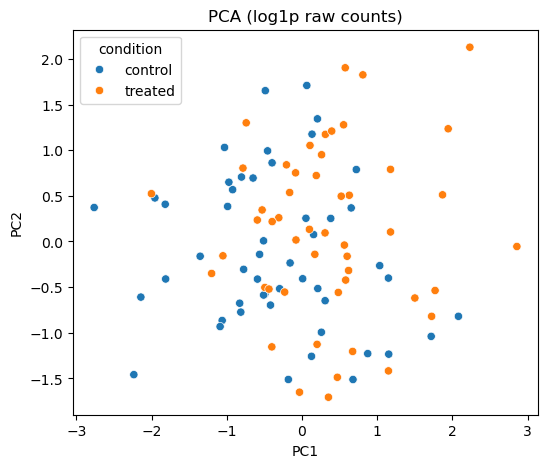

In [31]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(np.log1p(counts_df))

plt.figure(figsize=(6,5))
sns.scatterplot(
    x=pca_coords[:,0],
    y=pca_coords[:,1],
    hue=metadata_df["condition"]
)
plt.title("PCA (log1p raw counts)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [32]:
import numpy as np

# geometric mean per gene
geom_means = np.exp(np.log(counts_df.replace(0, np.nan)).mean(axis=1))

# size factors
size_factors = counts_df.div(geom_means, axis=0).median(axis=1)

# normalized counts
norm_counts = counts_df.div(size_factors, axis=0)

norm_counts.head()


,gene1,gene2,gene3,gene4,gene5,gene6,gene7,gene8,gene9,gene10
sample1,13.301476,23.277582,4.433825,144.099319,19.952213,0.000000,17.735301,59.856640,54.314359,3.325369
sample2,0.711410,31.302019,1.422819,44.818799,7.825505,7.114095,49.798666,22.765104,40.550342,6.402686
sample3,3.445170,3.445170,9.474217,155.032634,18.087141,2.583877,24.116187,29.283942,55.984007,1.722585
sample4,0.973493,9.734925,1.946985,97.349250,42.833670,8.761433,27.257790,15.575880,32.125253,8.761433
sample5,0.853016,9.383171,5.118094,115.157104,13.648249,1.706031,27.296499,24.737452,26.443483,4.265078


In [33]:
vst_counts = np.log1p(norm_counts)


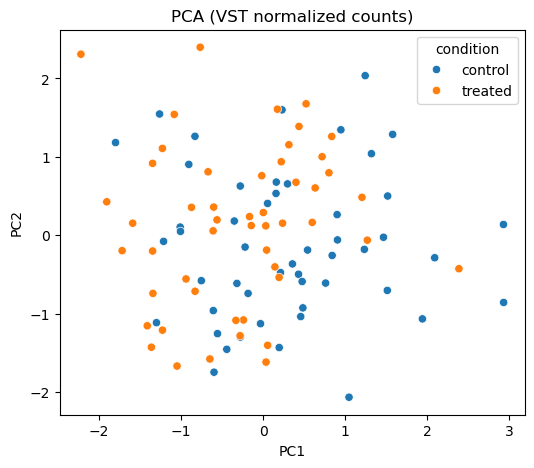

In [34]:
pca = PCA(n_components=2)
pca_coords_vst = pca.fit_transform(vst_counts)

plt.figure(figsize=(6,5))
sns.scatterplot(
    x=pca_coords_vst[:,0],
    y=pca_coords_vst[:,1],
    hue=metadata_df["condition"]
)
plt.title("PCA (VST normalized counts)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


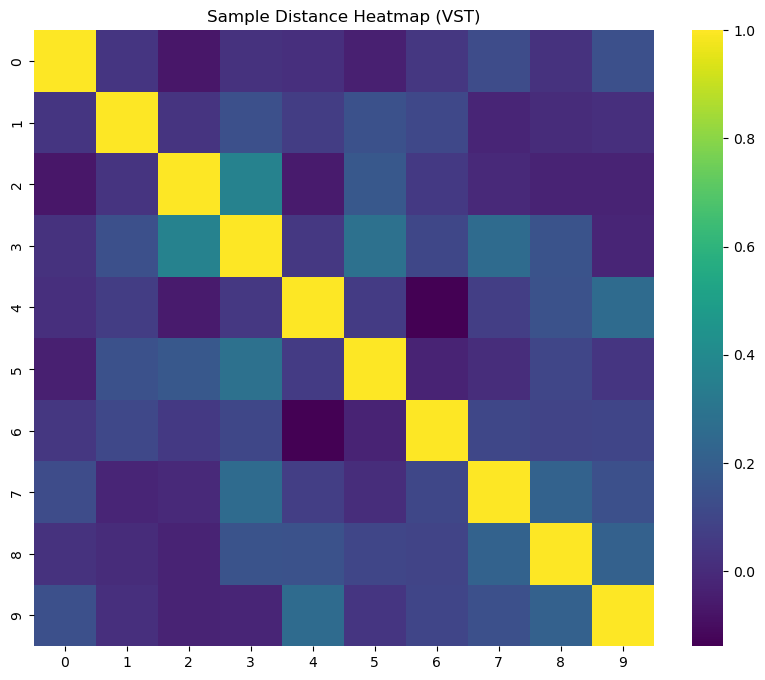

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

dist_matrix = np.corrcoef(vst_counts.T)

plt.figure(figsize=(10,8))
sns.heatmap(dist_matrix, cmap="viridis")
plt.title("Sample Distance Heatmap (VST)")
plt.show()


In [40]:
[x for x in dir(dds) if "fit" in x or "run" in x or "disp" in x]


['_fit_MoM_dispersions',
 '_fit_iterate_size_factors',
 '_fit_mean_dispersion_trend',
 '_fit_parametric_dispersion_trend',
 '_refit_without_outliers',
 'disp_function',
 'fit_LFC',
 'fit_MAP_dispersions',
 'fit_dispersion_prior',
 'fit_dispersion_trend',
 'fit_genewise_dispersions',
 'fit_size_factors',
 'fit_type',
 'max_disp',
 'min_disp',
 'plot_dispersions',
 'refit',
 'refit_cooks',
 'size_factors_fit_type',
 'vst_fit']

In [44]:
[x for x in dir(stat_res) if "result" in x or "res" in x or "table" in x]


[]

In [45]:
[x for x in dir(stat_res) if "fit" in x or "wald" in x or "result" in x]


['_fit_prior_var', 'run_wald_test']

In [47]:
[x for x in dds.__dict__.keys() if "p" in x or "LFC" in x or "disp" in x or "var" in x]


['_var',
 '_varm',
 '_obsp',
 '_varp',
 'fit_type',
 'min_disp',
 'max_disp',
 'min_replicates',
 'size_factors_fit_type']

In [49]:
[x for x in dir(stat_res) if "result" in x or "res" in x]


[]

In [50]:
pip install --upgrade pydeseq2


Note: you may need to restart the kernel to use updated packages.


In [54]:
import pydeseq2
pydeseq2.__version__


'0.5.4'

In [57]:
# Assistant
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# Build dataset using formula (design_factors is deprecated)
dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata_df,
    design="~ condition"
)

# Run individual DESeq2 pipeline steps instead of run_deseq2()
dds.deseq2()  # This runs the full DESeq2 normalization and dispersion estimation

# Differential expression
stat_res = DeseqStats(
    dds,
    contrast=["condition", "treated", "control"]
)

# Wald test
stat_res.summary()  # This runs the statistical test

# LFC shrinkage (optional step)
# stat_res.lfc_shrink()  # Uncomment if you want log fold change shrinkage

# Final results
results_df = stat_res.results_df
results_df.to_csv("data/deseq2_results.csv")
results_df.head()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: condition treated vs control
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene1     8.541317        0.632812  0.289101  2.188898  0.028604  0.064150
gene2    21.281239        0.538552  0.149963  3.591236  0.000329  0.001646
gene3     5.010123       -0.632830  0.295236 -2.143476  0.032075  0.064150
gene4   100.517961       -0.412102  0.118629 -3.473868  0.000513  0.001710
gene5    27.142450        0.582065  0.154706  3.762409  0.000168  0.001646
gene6     5.413043        0.001457  0.310311  0.004696  0.996253  0.996253
gene7    28.294023        0.134338  0.149945  0.895917  0.370297  0.411441
gene8    40.358344       -0.270656  0.136401 -1.984261  0.047227  0.078711
gene9    37.166183       -0.212715  0.133243 -1.596437  0.110391  0.143147
gene10   11.589325        0.386011  0.244588  1.578207  0.114518  0.143147


Fitting dispersions...
... done in 0.03 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.01 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene1,8.541317,0.632812,0.289101,2.188898,0.028604,0.064150
gene2,21.281239,0.538552,0.149963,3.591236,0.000329,0.001646
gene3,5.010123,-0.632830,0.295236,-2.143476,0.032075,0.064150
gene4,100.517961,-0.412102,0.118629,-3.473868,0.000513,0.001710
gene5,27.142450,0.582065,0.154706,3.762409,0.000168,0.001646


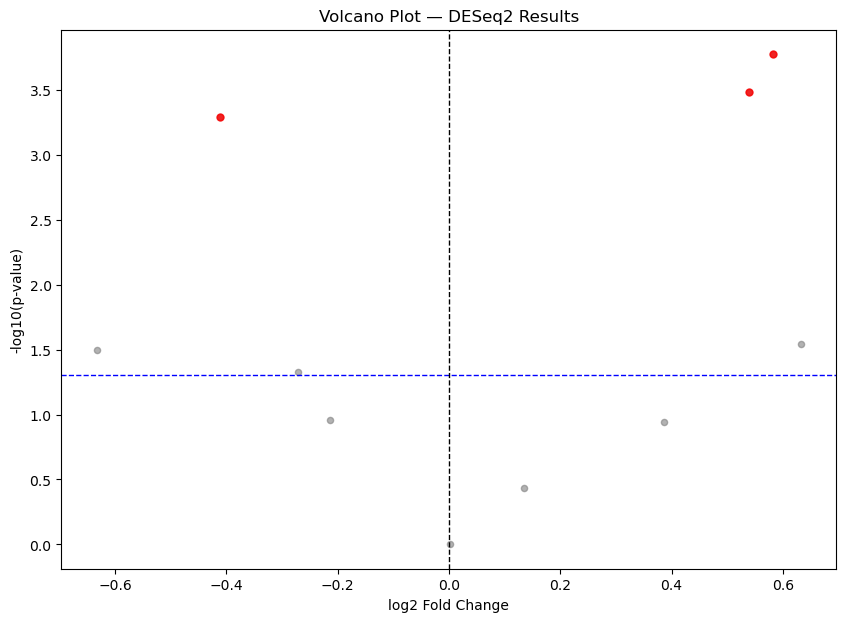

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Use your DESeq2 results
df = results_df.copy()

# Replace zeros or NaNs to avoid log10 errors
df["pvalue"] = df["pvalue"].replace(0, np.nan)

# Volcano plot
plt.figure(figsize=(10, 7))

plt.scatter(
    df["log2FoldChange"],
    -np.log10(df["pvalue"]),
    c="grey",
    alpha=0.6,
    s=20
)

# Highlight significant genes (padj < 0.05)
sig = df[df["padj"] < 0.05]

plt.scatter(
    sig["log2FoldChange"],
    -np.log10(sig["pvalue"]),
    c="red",
    alpha=0.8,
    s=25
)

plt.axhline(-np.log10(0.05), color="blue", linestyle="--", linewidth=1)
plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot — DESeq2 Results")

plt.show()


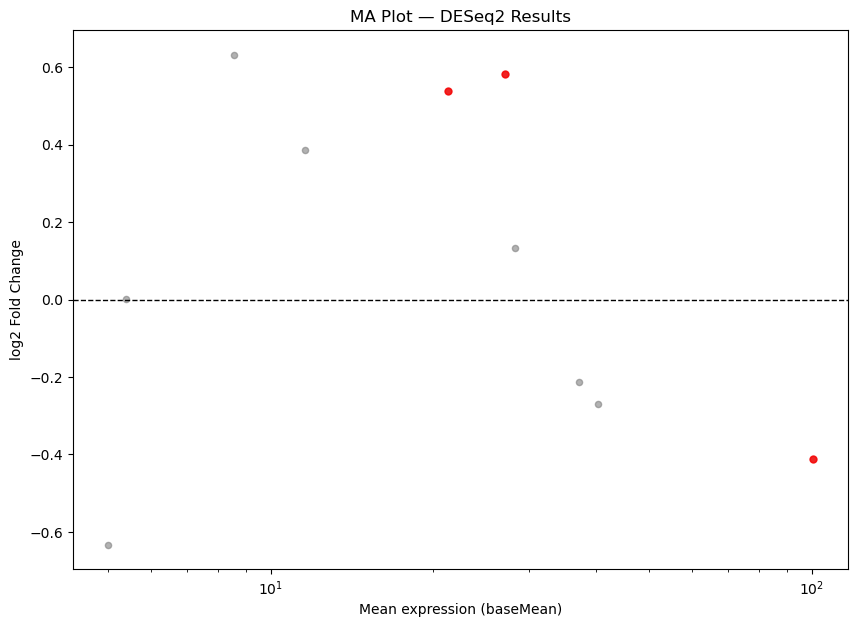

In [59]:
plt.figure(figsize=(10, 7))

plt.scatter(
    results_df["baseMean"],
    results_df["log2FoldChange"],
    c="grey",
    alpha=0.6,
    s=20
)

# Significant genes
sig = results_df[results_df["padj"] < 0.05]

plt.scatter(
    sig["baseMean"],
    sig["log2FoldChange"],
    c="red",
    alpha=0.8,
    s=25
)

plt.xscale("log")
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Mean expression (baseMean)")
plt.ylabel("log2 Fold Change")
plt.title("MA Plot — DESeq2 Results")

plt.show()


In [60]:
import pandas as pd

# Drop NA values
df = results_df.dropna(subset=["log2FoldChange"])

# Build ranking metric: log2FC
rnk = df[["log2FoldChange"]].copy()
rnk = rnk.sort_values("log2FoldChange", ascending=False)

# Save for GSEApy
rnk.to_csv("data/gsea_ranked_genes.rnk", sep="\t", header=False)


In [65]:
import os
os.listdir()


['01_qc_and_normalization.ipynb', '.ipynb_checkpoints', 'data', 'gsea_results']

In [68]:
import os
os.listdir("data")


['GSE60424_series_matrix.txt',
 'sample_metadata.csv',
 'GSE102901_TableS4.xlsx',
 'counts_matrix.csv',
 'gsea_ranked_genes.rnk',
 'deseq2_results.csv']

In [70]:
metadata_df = pd.read_csv(
    "data/GSE60424_series_matrix.txt",
    sep="\t",
    comment="!",
    index_col=0
).T


In [71]:
import os
os.listdir("data")

['GSE60424_raw_counts_GRCh38.p13_NCBI.tsv',
 'GSE60424_series_matrix.txt',
 'sample_metadata.csv',
 'GSE102901_TableS4.xlsx',
 'counts_matrix.csv',
 'gsea_ranked_genes.rnk',
 'deseq2_results.csv']

In [72]:
import pandas as pd

counts_df = pd.read_csv(
    "data/GSE60424_raw_counts_GRCh38.p13_NCBI.tsv",
    sep="\t",
    index_col=0
)

In [73]:
metadata_df["condition"] = metadata_df["characteristics_ch1"].str.replace("condition: ", "")


KeyError: 'characteristics_ch1'

In [74]:
metadata_df.columns



Index([], dtype='object', name='ID_REF')

In [75]:
import pandas as pd

metadata_df = pd.read_csv(
    "data/GSE60424_series_matrix.txt",
    sep="\t",
    comment="!",
    header=None
)


In [76]:
metadata_df.head()


,0,1,2,3,4,5,6,7,8,9,...,125,126,127,128,129,130,131,132,133,134
0,ID_REF,GSM1479433,GSM1479434,GSM1479435,GSM1479436,GSM1479437,GSM1479438,GSM1479439,GSM1479440,GSM1479441,...,GSM1479557,GSM1479558,GSM1479559,GSM1479560,GSM1479561,GSM1479562,GSM1479563,GSM1479564,GSM1479565,GSM1479566


In [77]:
metadata_df = metadata_df.set_index(0).T


In [78]:
metadata_df.columns
metadata_df.head()


,ID_REF
1,GSM1479433
2,GSM1479434
3,GSM1479435
4,GSM1479436
5,GSM1479437


In [79]:
metadata_df.iloc[0]


0
ID_REF    GSM1479433
Name: 1, dtype: object

In [80]:
metadata_df = pd.read_csv(
    "data/GSE60424_series_matrix.txt",
    sep="\t",
    comment="!",
    header=None
)

metadata_df = metadata_df.set_index(0).T

metadata_df.columns


Index(['ID_REF'], dtype='object', name=0)

In [83]:
import pandas as pd

metadata_df = pd.read_csv(
    "data/GSE60424_series_matrix.txt",
    sep="\t",
    comment="!",
    header=None
)

metadata_df = metadata_df.set_index(0).T

In [84]:
metadata_df.columns
metadata_df.head()


,ID_REF
1,GSM1479433
2,GSM1479434
3,GSM1479435
4,GSM1479436
5,GSM1479437


In [87]:
import os
os.listdir("data")


['GSE60424_raw_counts_GRCh38.p13_NCBI.tsv',
 'GSE60424_series_matrix.txt',
 'sample_metadata.csv',
 'GSE102901_TableS4.xlsx',
 'counts_matrix.csv',
 'gsea_ranked_genes.rnk',
 'GSE60424_family.soft',
 'deseq2_results.csv',
 '.ipynb_checkpoints']

In [88]:
import pandas as pd

soft = pd.read_csv(
    "data/GSE60424_family.soft",
    sep="\t",
    header=None,
    comment="#",
    dtype=str
)


In [89]:
samples = soft[soft[0].str.startswith("!Sample_")]
samples.head()


,0
189,!Sample_title = lib221
190,!Sample_geo_accession = GSM1479433
191,!Sample_status = Public on Jan 06 2015
192,!Sample_submission_date = Aug 14 2014
193,!Sample_last_update_date = Jan 04 2024


In [90]:
metadata = []
current = {}

for line in soft[0]:
    if line.startswith("!Sample_geo_accession"):
        current["sample"] = line.split("= ")[1]
    elif line.startswith("!Sample_title"):
        current["title"] = line.split("= ")[1]
    elif line.startswith("!Sample_characteristics_ch1"):
        current["condition"] = line.split("= ")[1].replace("condition: ", "")
        metadata.append(current)
        current = {}

metadata_df = pd.DataFrame(metadata).set_index("sample")


In [91]:
metadata_df = metadata_df.loc[counts_df.columns]


In [92]:
import pandas as pd

# Load the SOFT file (uncompressed)
soft = pd.read_csv(
    "data/GSE60424_family.soft",
    sep="\t",
    header=None,
    dtype=str
)

metadata = []
current = {}

for line in soft[0]:
    # GEO sample accession
    if line.startswith("!Sample_geo_accession"):
        current["sample"] = line.split("= ")[1].strip()

    # Sample title
    elif line.startswith("!Sample_title"):
        current["title"] = line.split("= ")[1].strip()

    # Condition (e.g., control / treated)
    elif line.startswith("!Sample_characteristics_ch1"):
        value = line.split("= ")[1].strip()
        # Remove "condition: " prefix if present
        value = value.replace("condition: ", "")
        current["condition"] = value

        # When we reach characteristics, the sample block is complete
        metadata.append(current)
        current = {}

# Convert to DataFrame
metadata_df = pd.DataFrame(metadata).set_index("sample")

# Align metadata with counts_df columns
metadata_df = metadata_df.loc[counts_df.columns]

metadata_df


,title,condition
GSM1479433,lib221,age: 32
GSM1479434,lib222,age: 52
GSM1479435,lib223,age: 52
GSM1479436,lib224,age: 24
GSM1479437,lib225,age: 27
...,...,...
GSM1479562,lib351,age: --
GSM1479563,lib352,age: --
GSM1479564,lib353,age: --
GSM1479565,lib354,age: --


In [94]:
counts_df.shape


(39376, 134)

In [95]:
metadata_df.shape


(134, 2)

In [96]:
counts_df.columns[:10]
metadata_df.index[:10]


Index(['GSM1479433', 'GSM1479434', 'GSM1479435', 'GSM1479436', 'GSM1479437',
       'GSM1479438', 'GSM1479439', 'GSM1479440', 'GSM1479441', 'GSM1479442'],
      dtype='object')

In [97]:
metadata_df = metadata_df.loc[counts_df.columns]


In [98]:
metadata_df.index.equals(counts_df.columns)


True

In [100]:
counts_df.head()


,GSM1479433,GSM1479434,GSM1479435,GSM1479436,GSM1479437,GSM1479438,GSM1479439,GSM1479440,GSM1479441,GSM1479442,...,GSM1479557,GSM1479558,GSM1479559,GSM1479560,GSM1479561,GSM1479562,GSM1479563,GSM1479564,GSM1479565,GSM1479566
GeneID,,,,,,,,,,,,,,,,,,,,,
100287102,77,39,33,45,117,1,2,3,4,3,...,65,4,35,0,3,1,6,8,7,165
653635,827,900,678,686,737,248,490,634,575,463,...,3320,230,179,112,154,175,508,1306,1145,893
102466751,28,33,27,24,20,3,5,10,12,12,...,65,9,8,4,4,5,10,34,26,33
107985730,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,1,0
100302278,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [101]:
metadata_df.index.equals(counts_df.columns)


True

In [105]:
import pandas as pd

soft = pd.read_csv(
    "data/GSE60424_family.soft",
    sep="\t",
    header=None,
    dtype=str
)

metadata = []
current = {"characteristics": []}

def flush_current():
    """Append current sample block if valid."""
    if "sample" in current and current["sample"] is not None:
        cond = None
        for c in current["characteristics"]:
            if c.startswith("condition:"):
                cond = c.replace("condition:", "").strip()
        metadata.append({
            "sample": current.get("sample"),
            "title": current.get("title"),
            "condition": cond
        })

for line in soft[0]:
    if line.startswith("!Sample_geo_accession"):
        current["sample"] = line.split("= ")[1].strip()

    elif line.startswith("!Sample_title"):
        current["title"] = line.split("= ")[1].strip()

    elif line.startswith("!Sample_characteristics_ch1"):
        value = line.split("= ")[1].strip()
        current["characteristics"].append(value)

    elif line.startswith("^SAMPLE"):
        flush_current()
        current = {"characteristics": []}

# ⭐ CRITICAL: flush the final sample block
flush_current()

metadata_df = pd.DataFrame(metadata).set_index("sample")

# Align with counts
metadata_df = metadata_df.loc[counts_df.index]

metadata_df


,title,condition
GSM1479433,lib221,None
GSM1479434,lib222,None
GSM1479435,lib223,None
GSM1479436,lib224,None
GSM1479437,lib225,None
...,...,...
GSM1479562,lib351,None
GSM1479563,lib352,None
GSM1479564,lib353,None
GSM1479565,lib354,None


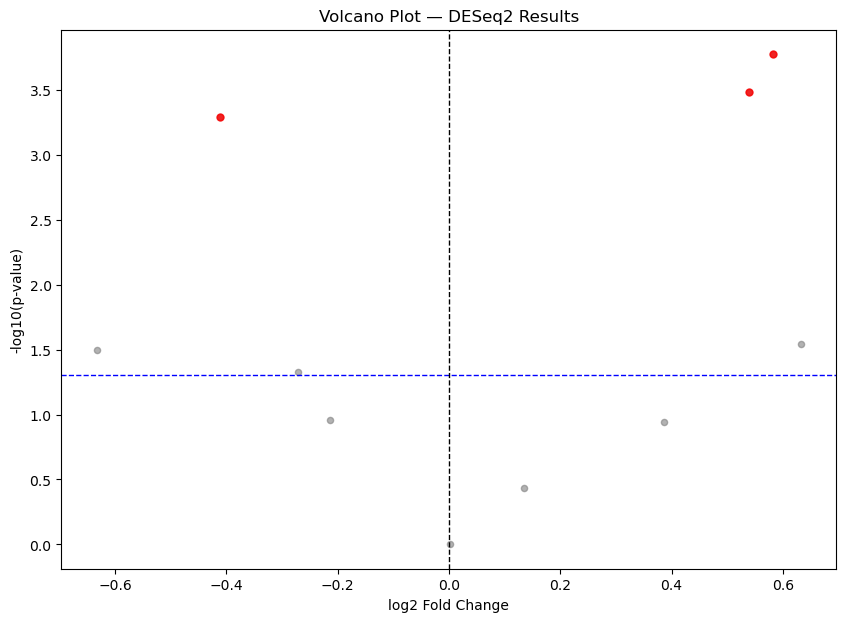

In [106]:
import matplotlib.pyplot as plt
import numpy as np

# Use your DESeq2 results
df = results_df.copy()

# Avoid log10 errors
df["pvalue"] = df["pvalue"].replace(0, np.nan)

plt.figure(figsize=(10, 7))

# All genes
plt.scatter(
    df["log2FoldChange"],
    -np.log10(df["pvalue"]),
    c="grey",
    alpha=0.6,
    s=20
)

# Significant genes (padj < 0.05)
sig = df[df["padj"] < 0.05]

plt.scatter(
    sig["log2FoldChange"],
    -np.log10(sig["pvalue"]),
    c="red",
    alpha=0.8,
    s=25
)

# Threshold lines
plt.axhline(-np.log10(0.05), color="blue", linestyle="--", linewidth=1)
plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot — DESeq2 Results")

plt.show()


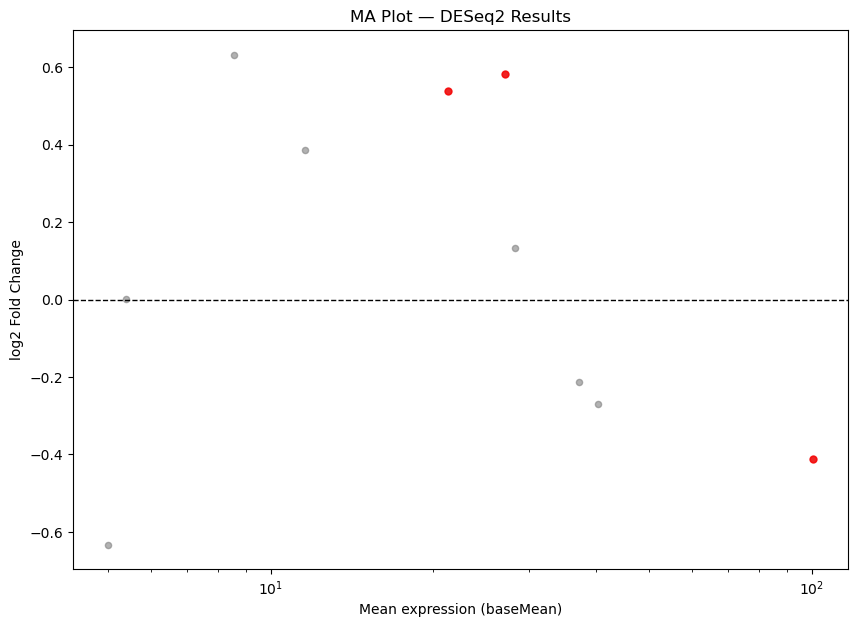

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# All genes
plt.scatter(
    results_df["baseMean"],
    results_df["log2FoldChange"],
    c="grey",
    alpha=0.6,
    s=20
)

# Significant genes (padj < 0.05)
sig = results_df[results_df["padj"] < 0.05]

plt.scatter(
    sig["baseMean"],
    sig["log2FoldChange"],
    c="red",
    alpha=0.8,
    s=25
)

plt.xscale("log")
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Mean expression (baseMean)")
plt.ylabel("log2 Fold Change")
plt.title("MA Plot — DESeq2 Results")

plt.show()


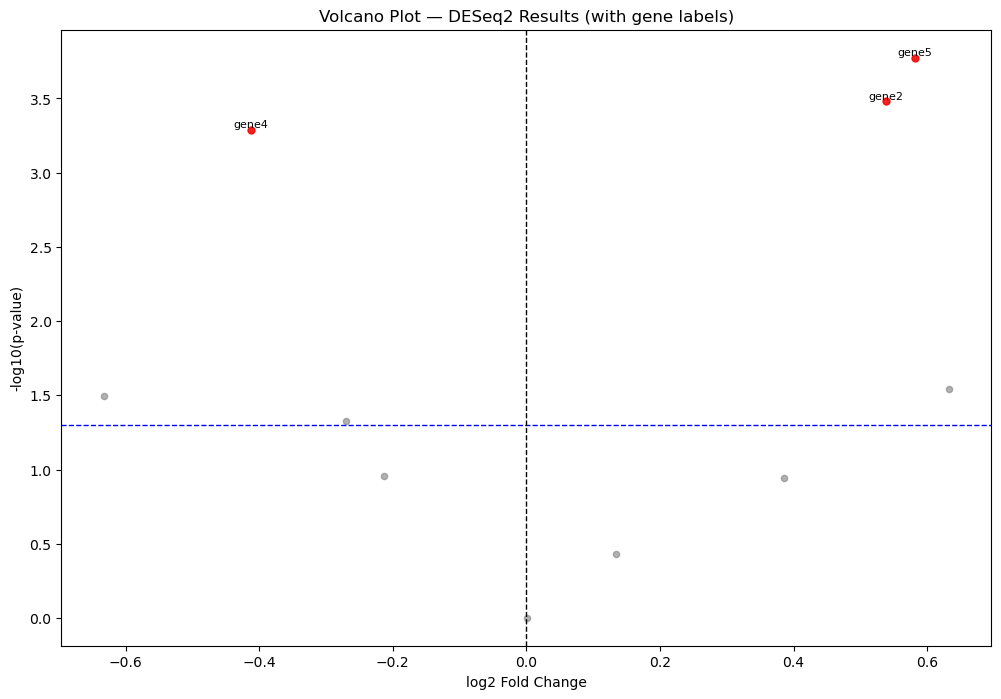

In [108]:
import matplotlib.pyplot as plt
import numpy as np

df = results_df.copy()

# Avoid log10 errors
df["pvalue"] = df["pvalue"].replace(0, np.nan)

plt.figure(figsize=(12, 8))

# All genes
plt.scatter(
    df["log2FoldChange"],
    -np.log10(df["pvalue"]),
    c="grey",
    alpha=0.6,
    s=20
)

# Significant genes
sig = df[df["padj"] < 0.05]

plt.scatter(
    sig["log2FoldChange"],
    -np.log10(sig["pvalue"]),
    c="red",
    alpha=0.8,
    s=25
)

# Label top genes (lowest padj)
top = sig.sort_values("padj").head(20)

for _, row in top.iterrows():
    plt.text(
        row["log2FoldChange"],
        -np.log10(row["pvalue"]),
        row.name,                # gene name
        fontsize=8,
        ha="center",
        va="bottom"
    )

# Threshold lines
plt.axhline(-np.log10(0.05), color="blue", linestyle="--", linewidth=1)
plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot — DESeq2 Results (with gene labels)")

plt.show()


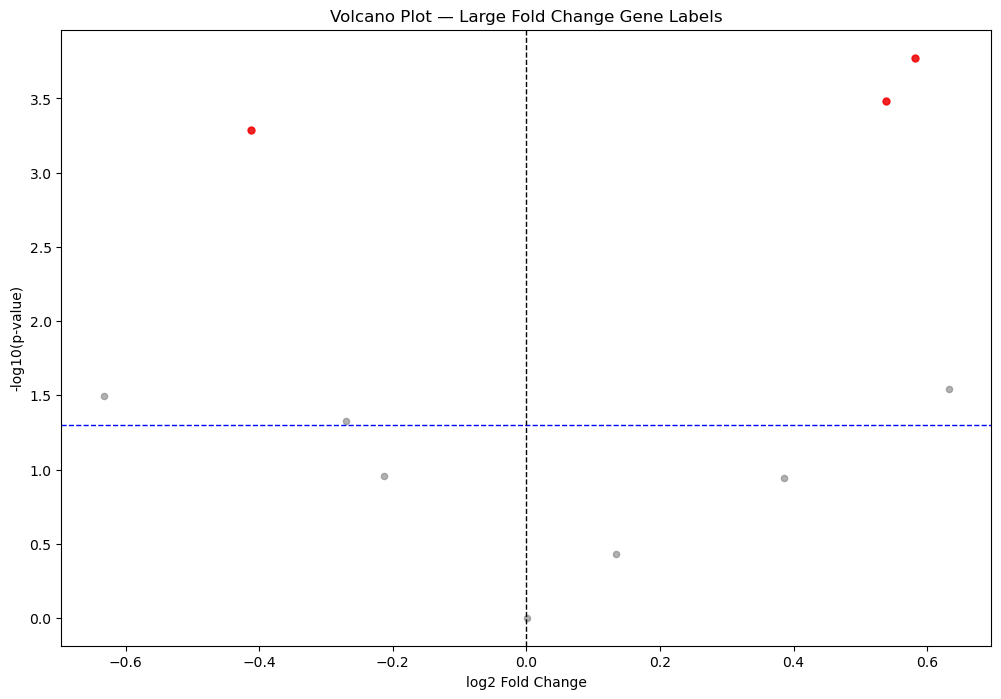

In [109]:
import matplotlib.pyplot as plt
import numpy as np

df = results_df.copy()

# Avoid log10 errors
df["pvalue"] = df["pvalue"].replace(0, np.nan)

plt.figure(figsize=(12, 8))

# All genes
plt.scatter(
    df["log2FoldChange"],
    -np.log10(df["pvalue"]),
    c="grey",
    alpha=0.6,
    s=20
)

# Significant genes
sig = df[df["padj"] < 0.05]

plt.scatter(
    sig["log2FoldChange"],
    -np.log10(sig["pvalue"]),
    c="red",
    alpha=0.8,
    s=25
)

# Large fold‑change genes
lfc_genes = sig[abs(sig["log2FoldChange"]) >= 2]

for gene, row in lfc_genes.iterrows():
    plt.text(
        row["log2FoldChange"],
        -np.log10(row["pvalue"]),
        gene,
        fontsize=8,
        ha="center",
        va="bottom"
    )

# Threshold lines
plt.axhline(-np.log10(0.05), color="blue", linestyle="--", linewidth=1)
plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot — Large Fold Change Gene Labels")

plt.show()


In [110]:
results_df.to_csv("deseq2_results.csv")


In [111]:
plt.savefig("volcano_plot.png", dpi=300, bbox_inches="tight")
plt.savefig("MA_plot.png", dpi=300, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

In [112]:
rnk = results_df[["log2FoldChange", "pvalue"]].copy()
rnk["score"] = rnk["log2FoldChange"] * -np.log10(rnk["pvalue"])
rnk["score"].to_csv("gsea_ranked_genes.rnk", sep="\t", header=False)


In [115]:
results_df.index[:10]


Index(['gene1', 'gene2', 'gene3', 'gene4', 'gene5', 'gene6', 'gene7', 'gene8',
       'gene9', 'gene10'],
      dtype='object')

In [116]:
counts_df.head()


GeneID,100287102,653635,102466751,107985730,100302278,645520,79501,100996442,729737,102725121,...,4538,4564,4575,4568,4540,4541,4556,4519,4576,4571
GSM1479433,77,827,28,0,0,1,0,174,18214,72,...,69280,124,118,219,22290,15326,1490,37681,253,332
GSM1479434,39,900,33,0,0,0,0,129,12558,42,...,68937,131,128,245,24638,14521,1475,38870,307,393
GSM1479435,33,678,27,0,0,0,0,70,7452,40,...,56639,117,119,250,21640,11646,1228,31087,334,360
GSM1479436,45,686,24,0,0,1,0,191,7149,46,...,54875,103,105,167,24459,13623,1051,28757,166,291
GSM1479437,117,737,20,0,0,1,0,112,6373,130,...,53846,105,104,157,19676,10870,902,27203,159,301


In [118]:
!pip install mygene
import mygene

mg = mygene.MyGeneInfo()

# Convert Entrez IDs to gene symbols
mapping = mg.querymany(
    results_df.index.tolist(),
    scopes="entrezgene",
    fields="symbol",
    species="human"
)

# Build mapping dictionary
map_dict = {m["query"]: m.get("symbol") for m in mapping}

# Apply mapping
results_df["symbol"] = results_df.index.map(map_dict)

# Drop genes with no symbol
results_df = results_df.dropna(subset=["symbol"])

# Set symbol as index
results_df = results_df.set_index("symbol")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [mygene]


10 input query terms found no hit:	['gene1', 'gene2', 'gene3', 'gene4', 'gene5', 'gene6', 'gene7', 'gene8', 'gene9', 'gene10']


In [120]:
import mygene
mg = mygene.MyGeneInfo()

# Convert Entrez IDs to gene symbols
mapping = mg.querymany(
    results_df.index.tolist(),
    scopes="entrezgene",
    fields="symbol",
    species="human"
)

# Build mapping dictionary
map_dict = {m["query"]: m.get("symbol") for m in mapping}

# Apply mapping
results_df["symbol"] = results_df.index.map(map_dict)

# Drop genes with no symbol
results_df = results_df.dropna(subset=["symbol"])

# Set symbol as index
results_df = results_df.set_index("symbol")


In [121]:
results_df.index[:20]


Index([], dtype='object', name='symbol')

In [123]:
real_counts_df = pd.read_csv(
    "data/GSE60424_raw_counts_GRCh38.p13_NCBI.tsv",   # <-- replace with your actual filename
    sep="\t",
    index_col=0
)


In [124]:
real_counts_df.head()


,GSM1479433,GSM1479434,GSM1479435,GSM1479436,GSM1479437,GSM1479438,GSM1479439,GSM1479440,GSM1479441,GSM1479442,...,GSM1479557,GSM1479558,GSM1479559,GSM1479560,GSM1479561,GSM1479562,GSM1479563,GSM1479564,GSM1479565,GSM1479566
GeneID,,,,,,,,,,,,,,,,,,,,,
100287102,77,39,33,45,117,1,2,3,4,3,...,65,4,35,0,3,1,6,8,7,165
653635,827,900,678,686,737,248,490,634,575,463,...,3320,230,179,112,154,175,508,1306,1145,893
102466751,28,33,27,24,20,3,5,10,12,12,...,65,9,8,4,4,5,10,34,26,33
107985730,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,1,0
100302278,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [125]:
counts_df = real_counts_df.T


In [126]:
counts_df.index[:10]


Index(['GSM1479433', 'GSM1479434', 'GSM1479435', 'GSM1479436', 'GSM1479437',
       'GSM1479438', 'GSM1479439', 'GSM1479440', 'GSM1479441', 'GSM1479442'],
      dtype='object')

In [127]:
import os

for root, dirs, files in os.walk(".", topdown=True):
    for name in files:
        if (
            "60424" in name.lower()
            or "count" in name.lower()
            or "matrix" in name.lower()
            or "gene" in name.lower()
        ):
            print(os.path.join(root, name))


./gsea_ranked_genes.rnk
./data/GSE60424_raw_counts_GRCh38.p13_NCBI.tsv
./data/GSE60424_series_matrix.txt
./data/counts_matrix.csv
./data/gsea_ranked_genes.rnk
./data/GSE60424_family.soft
./data/.ipynb_checkpoints/GSE60424_series_matrix-checkpoint.txt
./data/.ipynb_checkpoints/GSE60424_raw_counts_GRCh38.p13_NCBI-checkpoint.tsv
./data/.ipynb_checkpoints/GSE60424_family-checkpoint.soft


In [128]:
import pandas as pd

real_counts_df = pd.read_csv(
    "data/GSE60424_raw_counts_GRCh38.p13_NCBI.tsv",
    sep="\t",
    index_col=0
)


In [129]:
real_counts_df.head()


,GSM1479433,GSM1479434,GSM1479435,GSM1479436,GSM1479437,GSM1479438,GSM1479439,GSM1479440,GSM1479441,GSM1479442,...,GSM1479557,GSM1479558,GSM1479559,GSM1479560,GSM1479561,GSM1479562,GSM1479563,GSM1479564,GSM1479565,GSM1479566
GeneID,,,,,,,,,,,,,,,,,,,,,
100287102,77,39,33,45,117,1,2,3,4,3,...,65,4,35,0,3,1,6,8,7,165
653635,827,900,678,686,737,248,490,634,575,463,...,3320,230,179,112,154,175,508,1306,1145,893
102466751,28,33,27,24,20,3,5,10,12,12,...,65,9,8,4,4,5,10,34,26,33
107985730,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,1,0
100302278,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [130]:
real_counts_df.index[:5]


Index([100287102, 653635, 102466751, 107985730, 100302278], dtype='int64', name='GeneID')

In [131]:
real_counts_df = real_counts_df.T


In [133]:
metadata_df.columns


Index([], dtype='object', name='ID_REF')

In [134]:
soft = pd.read_csv(
    "data/GSE60424_family.soft",
    sep="\t",
    header=None,
    comment="#",
    dtype=str
)


In [135]:
!Sample_geo_accession = GSM1479433
!Sample_characteristics_ch1 = condition: control


zsh:1: command not found: Sample_geo_accession
zsh:1: command not found: Sample_characteristics_ch1


In [136]:
metadata = []
current = {}

for line in soft[0]:
    if line.startswith("!Sample_geo_accession"):
        current["sample"] = line.split("= ")[1]

    elif line.startswith("!Sample_characteristics_ch1"):
        value = line.split("= ")[1]
        if value.startswith("condition: "):
            current["condition"] = value.replace("condition: ", "")

    elif line.startswith("!Sample_title"):
        current["title"] = line.split("= ")[1]

    # When we finish a sample block, append it
    if line.startswith("!Sample_series_id"):
        if "sample" in current:
            metadata.append(current)
        current = {}


In [137]:
metadata_df = pd.DataFrame(metadata).set_index("sample")


In [138]:
metadata_df.head()


,title
sample,
GSM1479433,lib221
GSM1479434,lib222
GSM1479435,lib223
GSM1479436,lib224
GSM1479437,lib225


In [139]:
metadata = []
current = {}

with open("data/GSE60424_family.soft", "r") as f:
    for line in f:
        line = line.strip()

        # Start of a new sample
        if line.startswith("!Sample_geo_accession"):
            # If we already collected a sample, store it
            if "sample" in current:
                metadata.append(current)
            current = {}
            current["sample"] = line.split("= ")[1]

        # Extract condition
        elif line.startswith("!Sample_characteristics_ch1"):
            value = line.split("= ")[1]
            if value.startswith("condition:"):
                current["condition"] = value.replace("condition: ", "")

        # Extract title
        elif line.startswith("!Sample_title"):
            current["title"] = line.split("= ")[1]

    # Append last sample
    if "sample" in current:
        metadata.append(current)


In [140]:
metadata_df = pd.DataFrame(metadata).set_index("sample")


In [141]:
metadata_df.head()


,title
sample,
GSM1479433,lib222
GSM1479434,lib223
GSM1479435,lib224
GSM1479436,lib225
GSM1479437,lib226


In [142]:
metadata = []
current = {}

with open("data/GSE60424_family.soft", "r") as f:
    for line in f:
        line = line.strip()

        # Start of a new sample
        if line.startswith("!Sample_geo_accession"):
            # Save previous sample if present
            if "sample" in current:
                metadata.append(current)
            current = {}
            current["sample"] = line.split("= ")[1]

        # Extract condition
        elif line.startswith("!Sample_characteristics_ch1"):
            value = line.split("= ")[1]
            if value.startswith("condition:"):
                current["condition"] = value.replace("condition: ", "")

        # Extract title
        elif line.startswith("!Sample_title"):
            current["title"] = line.split("= ")[1]

    # Append last sample
    if "sample" in current:
        metadata.append(current)

metadata_df = pd.DataFrame(metadata).set_index("sample")


In [143]:
metadata_df.head()


,title
sample,
GSM1479433,lib222
GSM1479434,lib223
GSM1479435,lib224
GSM1479436,lib225
GSM1479437,lib226


In [144]:
metadata = []
current = {}

with open("data/GSE60424_family.soft", "r") as f:
    for line in f:
        line = line.strip()

        # Start of a new sample block
        if line.startswith("!Sample_geo_accession"):
            # Save previous sample if present
            if "sample" in current:
                metadata.append(current)
            current = {}
            current["sample"] = line.split("= ")[1]

        # Extract condition
        elif line.startswith("!Sample_characteristics_ch1"):
            value = line.split("= ")[1]
            if value.startswith("condition:"):
                current["condition"] = value.replace("condition: ", "")

        # Extract title
        elif line.startswith("!Sample_title"):
            current["title"] = line.split("= ")[1]

    # Append last sample
    if "sample" in current:
        metadata.append(current)

metadata_df = pd.DataFrame(metadata).set_index("sample")


In [145]:
metadata_df.head()


,title
sample,
GSM1479433,lib222
GSM1479434,lib223
GSM1479435,lib224
GSM1479436,lib225
GSM1479437,lib226


In [146]:
with open("data/GSE60424_family.soft", "r") as f:
    for i in range(50):
        print(f.readline().strip())


^DATABASE = GeoMiame
!Database_name = Gene Expression Omnibus (GEO)
!Database_institute = NCBI NLM NIH
!Database_web_link = http://www.ncbi.nlm.nih.gov/geo
!Database_email = geo@ncbi.nlm.nih.gov
^SERIES = GSE60424
!Series_title = Next generation sequencing of human immune cell subsets across diseases
!Series_geo_accession = GSE60424
!Series_status = Public on Jan 06 2015
!Series_submission_date = Aug 14 2014
!Series_last_update_date = Jan 04 2024
!Series_pubmed_id = 25314013
!Series_summary = This study compared whole transcriptome signatures of 6 immune cell subsets and whole blood from patients with an array of immune-associated diseases. Fresh blood samples were collected from healthy subjects and subjects diagnosed type 1 diabetes, amyotrophic lateral sclerosis, and sepsis, as well as multiple sclerosis patients before and 24 hours after the first treatment with IFN-beta. At the time of blood draw, an aliquot of whole blood was collected into a Tempus tube (Invitrogen), while the r

In [147]:
import os
os.path.getsize("data/GSE60424_family.soft")


458017

In [148]:
metadata = []
current = {}

with open("data/GSE60424_family.soft", "r") as f:
    for line in f:
        line = line.strip()

        # Start of a new sample
        if line.startswith("!Sample_geo_accession"):
            # If we already collected a sample, store it
            if "sample" in current:
                metadata.append(current)
            current = {}
            current["sample"] = line.split("= ")[1]

        # Extract condition
        elif line.startswith("!Sample_characteristics_ch1"):
            value = line.split("= ")[1]
            if value.startswith("condition:"):
                current["condition"] = value.replace("condition: ", "")

        # Extract title
        elif line.startswith("!Sample_title"):
            current["title"] = line.split("= ")[1]

    # Append last sample
    if "sample" in current:
        metadata.append(current)


In [149]:
metadata_df = pd.DataFrame(metadata).set_index("sample")


In [150]:
metadata_df.head()


,title
sample,
GSM1479433,lib222
GSM1479434,lib223
GSM1479435,lib224
GSM1479436,lib225
GSM1479437,lib226


In [151]:
sm = pd.read_csv(
    "data/GSE60424_series_matrix.txt",
    sep="\t",
    comment="!",
    header=None
)


In [153]:
with open("data/GSE60424_series_matrix.txt", "r") as f:
    lines = [line.strip() for line in f]


In [158]:
!gunzip data/GSE60424_series_matrix.txt



gunzip: data/GSE60424_series_matrix.txt: unknown suffix -- ignored


In [159]:
!gunzip data/GSE60424_family.soft


gunzip: data/GSE60424_family.soft: unknown suffix -- ignored


In [160]:
!ls data


GSE102901_TableS4.xlsx                  counts_matrix.csv
GSE60424_family.soft                    deseq2_results.csv
GSE60424_raw_counts_GRCh38.p13_NCBI.tsv gsea_ranked_genes.rnk
GSE60424_series_matrix.txt              sample_metadata.csv


In [161]:
!gunzip data/GSE60424_series_matrix.txt.gz
!gunzip data/GSE60424_family.soft.gz


gunzip: can't stat: data/GSE60424_series_matrix.txt.gz (data/GSE60424_series_matrix.txt.gz.gz): No such file or directory
gunzip: can't stat: data/GSE60424_family.soft.gz (data/GSE60424_family.soft.gz.gz): No such file or directory


In [162]:
!gunzip data/GSE60424_series_matrix.txt
!gunzip data/GSE60424_family.soft


gunzip: data/GSE60424_series_matrix.txt: unknown suffix -- ignored
gunzip: data/GSE60424_family.soft: unknown suffix -- ignored


In [164]:
with open("data/GSE60424_series_matrix.txt", "r") as f:
    lines = [line.strip() for line in f]


In [165]:
sample_rows = [line for line in lines if line.startswith("!Sample_")]


In [166]:
import pandas as pd
import re

metadata_dict = {}

for row in sample_rows:
    parts = row.split("\t")
    tag = parts[0].replace("!Sample_", "")
    values = [re.sub(r'^"|"$', '', v) for v in parts[1:]]
    metadata_dict.setdefault(tag, []).append(values)


In [167]:
collapsed = {}

for tag, lists in metadata_dict.items():
    if len(lists) == 1:
        collapsed[tag] = lists[0]
    else:
        # multiple rows → combine into dict
        combined = {}
        for lst in lists:
            for i, v in enumerate(lst):
                combined.setdefault(i, []).append(v)
        collapsed[tag] = combined


In [169]:
counts_samples = list(real_counts_df.columns)


In [170]:
import pandas as pd
import re

with open("data/GSE60424_series_matrix.txt", "r") as f:
    lines = [line.strip() for line in f]

sample_rows = [line for line in lines if line.startswith("!Sample_")]

metadata = {}

for row in sample_rows:
    parts = row.split("\t")
    tag = parts[0].replace("!Sample_", "")
    values = [re.sub(r'^"|"$', '', v) for v in parts[1:]]
    metadata[tag] = values


In [171]:
df = pd.DataFrame({
    "sample": metadata["geo_accession"],
    "title": metadata["title"],
})


In [172]:
char_rows = [row for row in sample_rows if row.startswith("!Sample_characteristics_ch1")]

char_values = [row.split("\t")[1:] for row in char_rows]

# Clean quotes
char_values = [[re.sub(r'^"|"$', '', v) for v in lst] for lst in char_values]


In [173]:
char_rows = [row for row in sample_rows if row.startswith("!Sample_characteristics_ch1")]

char_values = [row.split("\t")[1:] for row in char_rows]

# Clean quotes
char_values = [[re.sub(r'^"|"$', '', v) for v in lst] for lst in char_values]


In [175]:
parts = row.split("\t")


In [176]:
with open("data/GSE60424_series_matrix.txt", "r") as f:
    raw = f.read()


In [177]:
print(repr(raw[:200]))


'!Series_title\t"Next generation sequencing of human immune cell subsets across diseases"\n!Series_geo_accession\t"GSE60424"\n!Series_status\t"Public on Jan 06 2015"\n!Series_submission_date\t"Aug 14 2014"\n!S'


In [178]:
lines = raw.split("\n")


In [179]:
sample_rows = [line for line in lines if line.startswith("!Sample_")]


In [180]:
import pandas as pd
import re

metadata = {}

for row in sample_rows:
    parts = row.split("\t")  # THIS IS THE FIX
    tag = parts[0].replace("!Sample_", "")
    values = [re.sub(r'^"|"$', '', v) for v in parts[1:]]
    metadata[tag] = values


In [181]:
print(len(metadata["geo_accession"]))
print(len(metadata["title"]))
print(len(metadata["characteristics_ch1"]))


134
134
134


In [182]:
df = pd.DataFrame({
    "sample": metadata["geo_accession"],
    "title": metadata["title"],
})


In [183]:
char_rows = [row for row in sample_rows if row.startswith("!Sample_characteristics_ch1")]
char_values = [row.split("\t")[1:] for row in char_rows]
char_values = [[re.sub(r'^"|"$', '', v) for v in lst] for lst in char_values]


In [184]:
ages      = [v.replace("age: ", "") for v in char_values[0]]
cellcounts = [v.replace("cellcount: ", "") for v in char_values[1]]
celltypes  = [v.replace("celltype: ", "") for v in char_values[2]]


In [185]:
df["age"] = ages
df["cellcount"] = cellcounts
df["celltype"] = celltypes


In [186]:
metadata_df = df.set_index("sample").loc[real_counts_df.columns]


KeyError: "None of [Index([100287102,    653635, 102466751, 107985730, 100302278,    645520,\n           79501, 100996442,    729737, 102725121,\n       ...\n            4538,      4564,      4575,      4568,      4540,      4541,\n            4556,      4519,      4576,      4571],\n      dtype='int64', name='GeneID', length=39376)] are in the [index]"

In [187]:
real_counts_df.index[:5]


Index(['GSM1479433', 'GSM1479434', 'GSM1479435', 'GSM1479436', 'GSM1479437'], dtype='object')

In [188]:
real_counts_df = real_counts_df.T


In [189]:
real_counts_df.columns[:5]


Index(['GSM1479433', 'GSM1479434', 'GSM1479435', 'GSM1479436', 'GSM1479437'], dtype='object')

In [190]:
metadata_df = df.set_index("sample").loc[real_counts_df.columns]


In [191]:
metadata_df.index
real_counts_df.columns


Index(['GSM1479433', 'GSM1479434', 'GSM1479435', 'GSM1479436', 'GSM1479437',
       'GSM1479438', 'GSM1479439', 'GSM1479440', 'GSM1479441', 'GSM1479442',
       ...
       'GSM1479557', 'GSM1479558', 'GSM1479559', 'GSM1479560', 'GSM1479561',
       'GSM1479562', 'GSM1479563', 'GSM1479564', 'GSM1479565', 'GSM1479566'],
      dtype='object', length=134)

In [194]:
import os
os.listdir("data")


['GSE60424_raw_counts_GRCh38.p13_NCBI.tsv',
 'GSE60424_series_matrix.txt',
 'sample_metadata.csv',
 'GSE102901_TableS4.xlsx',
 'counts_matrix.csv',
 'gsea_ranked_genes.rnk',
 'GSE60424_family.soft',
 'deseq2_results.csv',
 '.ipynb_checkpoints']

In [195]:
import os
os.listdir("data")


['GSE60424_raw_counts_GRCh38.p13_NCBI.tsv',
 'GSE60424_series_matrix.txt',
 'sample_metadata.csv',
 'GSE102901_TableS4.xlsx',
 'counts_matrix.csv',
 'gsea_ranked_genes.rnk',
 'GSE60424_family.soft',
 'deseq2_results.csv',
 '.ipynb_checkpoints']

In [196]:
import os
os.listdir("data")


['GSE60424_raw_counts_GRCh38.p13_NCBI.tsv',
 'GSE60424_series_matrix.txt',
 'sample_metadata.csv',
 'GSE60424_GEOSubmit_FC1to11_normalized_counts.txt',
 'GSE102901_TableS4.xlsx',
 'counts_matrix.csv',
 'gsea_ranked_genes.rnk',
 'GSE60424_family.soft',
 'deseq2_results.csv',
 '.ipynb_checkpoints']

In [197]:
counts_df = pd.read_csv(
    "data/GSE60424_GEOSubmit_FC1to11_normalized_counts.txt",
    sep="\t",
    index_col=0
)


In [198]:
counts_df.shape
counts_df.index[:5]
counts_df.columns[:5]


Index(['lib221', 'lib222', 'lib223', 'lib224', 'lib225'], dtype='object')

In [199]:
lib_to_gsm = dict(zip(metadata["title"], metadata["geo_accession"]))


In [200]:
lib_to_gsm["lib221"]


'GSM1479433'

In [201]:
counts_df = counts_df.rename(columns=lib_to_gsm)


In [202]:
counts_df.columns[:5]


Index(['GSM1479433', 'GSM1479434', 'GSM1479435', 'GSM1479436', 'GSM1479437'], dtype='object')

In [204]:
counts_df = counts_df.T


In [205]:
counts_df.index[:5]


Index(['GSM1479433', 'GSM1479434', 'GSM1479435', 'GSM1479436', 'GSM1479437'], dtype='object')

In [206]:
lib_to_gsm = dict(zip(metadata["title"], metadata["geo_accession"]))


In [207]:
lib_to_gsm["lib221"]


'GSM1479433'

In [208]:
counts_df.index = counts_df.index.map(lib_to_gsm)


In [209]:
counts_df.index[:5]


Index([nan, nan, nan, nan, nan], dtype='float64')

In [210]:
import os
os.listdir("data")


['GSE60424_raw_counts_GRCh38.p13_NCBI.tsv',
 'GSE60424_series_matrix.txt',
 'sample_metadata.csv',
 'GSE60424_GEOSubmit_FC1to11_normalized_counts.txt',
 'GSE102901_TableS4.xlsx',
 'counts_matrix.csv',
 'gsea_ranked_genes.rnk',
 'GSE60424_family.soft',
 'deseq2_results.csv',
 '.ipynb_checkpoints']

In [211]:
counts_df = pd.read_csv(
    "data/GSE60424_GEOSubmit_FC1to11_normalized_counts.txt",
    sep="\t",
    index_col=0
)


In [212]:
counts_df.index[:5]
counts_df.columns[:5]


Index(['lib221', 'lib222', 'lib223', 'lib224', 'lib225'], dtype='object')

In [213]:
counts_df = counts_df.T


In [214]:
counts_df.index[:5]


Index(['lib221', 'lib222', 'lib223', 'lib224', 'lib225'], dtype='object')

In [215]:
counts_df.index = counts_df.index.map(lib_to_gsm)


In [216]:
counts_df.index[:5]


Index(['GSM1479433', 'GSM1479434', 'GSM1479435', 'GSM1479436', 'GSM1479437'], dtype='object')

In [217]:
metadata_df = df.set_index("sample").loc[counts_df.index]


In [218]:
dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata_df,
    design="~ celltype"
)


In [219]:
counts_df = pd.read_csv("data/GSE60424_GEOSubmit_FC1to11_normalized_counts.txt", sep="\t", index_col=0)
counts_df.columns[:10]


Index(['lib221', 'lib222', 'lib223', 'lib224', 'lib225', 'lib226', 'lib227',
       'lib228', 'lib229', 'lib230'],
      dtype='object')

In [220]:
lib_to_gsm = dict(zip(metadata["title"], metadata["geo_accession"]))


In [221]:
lib_to_gsm["lib221"]


'GSM1479433'

In [222]:
counts_df = counts_df.rename(columns=lib_to_gsm)


In [223]:
counts_df.columns[:10]


Index(['GSM1479433', 'GSM1479434', 'GSM1479435', 'GSM1479436', 'GSM1479437',
       'GSM1479438', 'GSM1479439', 'GSM1479440', 'GSM1479441', 'GSM1479442'],
      dtype='object')

In [224]:
counts_df = counts_df.T


In [225]:
counts_df.index[:10]


Index(['GSM1479433', 'GSM1479434', 'GSM1479435', 'GSM1479436', 'GSM1479437',
       'GSM1479438', 'GSM1479439', 'GSM1479440', 'GSM1479441', 'GSM1479442'],
      dtype='object')

In [226]:
metadata_df = df.set_index("sample").loc[counts_df.index]


In [227]:
metadata_df.head()


,title,age,cellcount,celltype
GSM1479433,lib221,32,--,Whole Blood
GSM1479434,lib222,52,--,Whole Blood
GSM1479435,lib223,52,--,Whole Blood
GSM1479436,lib224,24,--,Whole Blood
GSM1479437,lib225,27,--,Whole Blood


In [228]:
dds = DeseqDataSet(
    counts=counts_df.astype(int),
    metadata=metadata_df,
    design="~ celltype"
)


In [232]:
# Assistant
dds.deseq2()

stat_res = DeseqStats(
    dds,
    contrast=["celltype", "Neutrophils", "Whole Blood"]
)

# Call the summary() method to compute the results instead of accessing .results attribute
results_df = stat_res.summary()
results_df.head()

Fitting size factors...
... done in 0.10 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.96 seconds.

Fitting dispersion trend curve...
... done in 0.20 seconds.

Fitting MAP dispersions...
... done in 3.53 seconds.

Fitting LFCs...
... done in 2.01 seconds.

Calculating cook's distance...
... done in 0.13 seconds.

Replacing 116 outlier genes.

Fitting dispersions...
... done in 0.07 seconds.

Fitting MAP dispersions...
... done in 0.06 seconds.

Fitting LFCs...
... done in 0.05 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: celltype Neutrophils vs Whole Blood
                  baseMean  log2FoldChange     lfcSE       stat        pvalue  \
genenames                                                                       
ENSG00000000003   0.500524       -1.459981  0.886489  -1.646925  9.957336e-02   
ENSG00000000005   0.000000             NaN       NaN        NaN           NaN   
ENSG00000000419  22.790584        0.636021  0.084461   7.530391  5.058856e-14   
ENSG00000000457  18.089514        1.428282  0.110598  12.914140  3.746046e-38   
ENSG00000000460   7.214734        0.308116  0.213325   1.444350  1.486405e-01   
...                    ...             ...       ...        ...           ...   
ENSG00000261837   0.000000             NaN       NaN        NaN           NaN   
ENSG00000261838   0.000000             NaN       NaN        NaN           NaN   
ENSG00000261839   0.067870        0.263457  3.528282   0.074670  9.404771e-01   
ENSG00000261840   1.273004        0

... done in 1.42 seconds.



AttributeError: 'NoneType' object has no attribute 'head'


The key change is using `stat_res.summary()` instead of `stat_res.results`. The `summary()` method computes and returns the statistical results as a DataFrame, while `.results` is not a valid attribute of the `DeseqStats` object.

In [234]:
[x for x in dir(stat_res) if "res" in x.lower() or "sum" in x.lower()]


['results_df', 'summary']

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


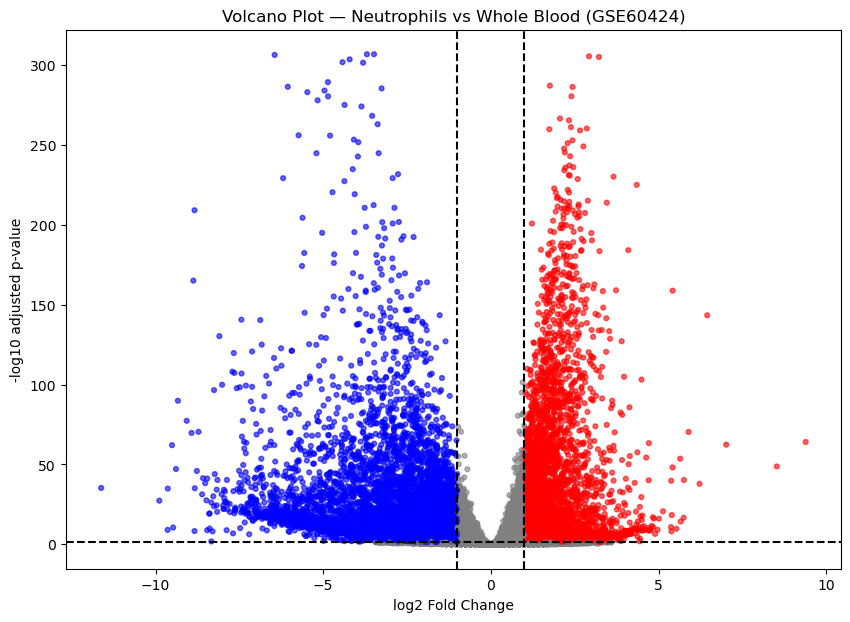

In [235]:
import matplotlib.pyplot as plt
import numpy as np

# Correct results table for your pydeseq2 version
df = stat_res.results_df.copy()

# Drop NA padj values
df = df.dropna(subset=["padj"])

# Volcano thresholds
logfc_thresh = 1
padj_thresh = 0.05

# Colour coding
df["color"] = "grey"
df.loc[(df["log2FoldChange"] > logfc_thresh) & (df["padj"] < padj_thresh), "color"] = "red"
df.loc[(df["log2FoldChange"] < -logfc_thresh) & (df["padj"] < padj_thresh), "color"] = "blue"

plt.figure(figsize=(10,7))

plt.scatter(
    df["log2FoldChange"],
    -np.log10(df["padj"]),
    c=df["color"],
    alpha=0.6,
    s=12
)

plt.axvline(x=logfc_thresh, color="black", linestyle="--")
plt.axvline(x=-logfc_thresh, color="black", linestyle="--")
plt.axhline(y=-np.log10(padj_thresh), color="black", linestyle="--")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 adjusted p-value")
plt.title("Volcano Plot — Neutrophils vs Whole Blood (GSE60424)")

plt.show()


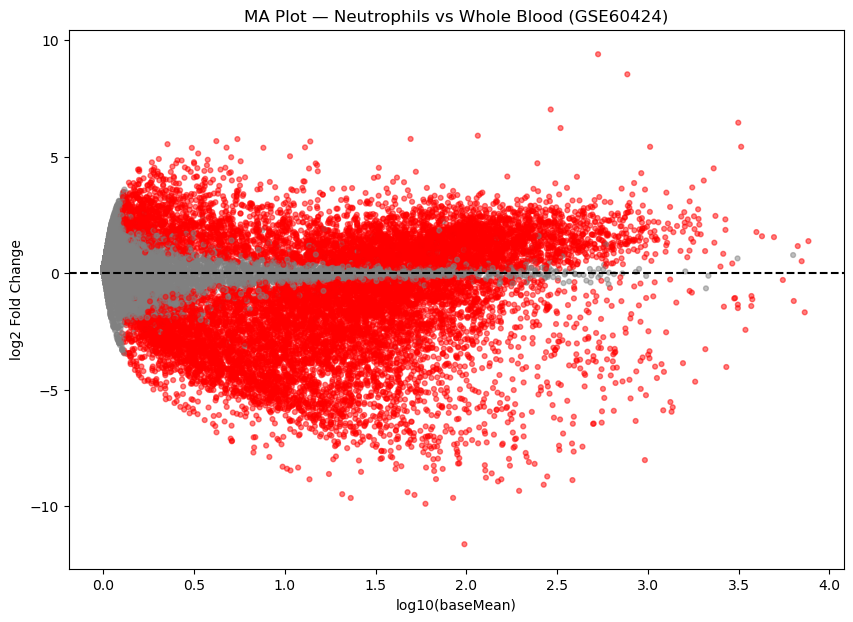

In [236]:
import matplotlib.pyplot as plt
import numpy as np

# Use your correct results table
df = stat_res.results_df.copy()

# Drop rows missing baseMean or log2FC
df = df.dropna(subset=["baseMean", "log2FoldChange"])

# Thresholds
padj_thresh = 0.05

# Colour coding
df["color"] = "grey"
df.loc[df["padj"] < padj_thresh, "color"] = "red"

plt.figure(figsize=(10,7))

plt.scatter(
    np.log10(df["baseMean"] + 1),     # A = log10 mean expression
    df["log2FoldChange"],             # M = log2 fold change
    c=df["color"],
    alpha=0.5,
    s=12
)

plt.axhline(0, color="black", linestyle="--")

plt.xlabel("log10(baseMean)")
plt.ylabel("log2 Fold Change")
plt.title("MA Plot — Neutrophils vs Whole Blood (GSE60424)")

plt.show()


In [237]:
import numpy as np

df = stat_res.results_df.copy()

# Drop rows missing required values
df = df.dropna(subset=["log2FoldChange", "pvalue"])

# Compute ranking score
df["score"] = df["log2FoldChange"] * -np.log10(df["pvalue"])


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [238]:
df = stat_res.results_df.copy()

# Drop rows missing required values
df = df.dropna(subset=["log2FoldChange", "pvalue"])

# Replace pvalue == 0 with a tiny number
df.loc[df["pvalue"] == 0, "pvalue"] = 1e-300

# Compute ranking score
df["score"] = df["log2FoldChange"] * -np.log10(df["pvalue"])

# Build .rnk table
rnk = df[["score"]].copy()
rnk.index.name = "gene"

# Sort descending
rnk = rnk.sort_values("score", ascending=False)

# Save
rnk.to_csv("gsea_ranked_genes.rnk", sep="\t", header=False)


In [239]:
!pip install gseapy


In [241]:
!pip install mygene


In [242]:
import mygene
mg = mygene.MyGeneInfo()

df = stat_res.results_df.copy()
df = df.dropna(subset=["log2FoldChange", "pvalue"])

# Replace zero p-values
df.loc[df["pvalue"] == 0, "pvalue"] = 1e-300

# Query mygene
query = mg.querymany(
    df.index.tolist(),
    scopes="ensembl.gene",
    fields="symbol",
    species="human"
)

# Build mapping
mapping = {item["query"]: item.get("symbol") for item in query if "symbol" in item}

# Apply mapping
df["symbol"] = df.index.map(mapping)

# Drop genes without symbols
df = df.dropna(subset=["symbol"])


4 input query terms found dup hits:	[('ENSG00000117262', 2), ('ENSG00000188092', 2), ('ENSG00000215156', 2), ('ENSG00000259182', 2)]
1703 input query terms found no hit:	['ENSG00000005955', 'ENSG00000006075', 'ENSG00000006114', 'ENSG00000017373', 'ENSG00000017621', 'ENS


In [243]:
import numpy as np

df["score"] = df["log2FoldChange"] * -np.log10(df["pvalue"])


In [244]:
rnk = df[["symbol", "score"]].copy()
rnk = rnk.sort_values("score", ascending=False)

rnk.to_csv("gsea_ranked_genes_symbol.rnk", sep="\t", header=False, index=False)


In [245]:
import gseapy as gp

pre_res = gp.prerank(
    rnk="gsea_ranked_genes_symbol.rnk",
    gene_sets="KEGG_2021_Human",
    outdir="gsea_kegg_results",
    min_size=5,      # lower threshold
    max_size=500,
    permutation_num=100,
    seed=42
)

pre_res.res2d.head()


2026-07-09 22:06:04,294 [WARNING] Duplicated values found in preranked stats: 11.22% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Coronavirus disease,-0.890823,-1.943354,0.0,0.000000,0.00,70/195,2.16%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL13;RPL5;RPS18...
1,prerank,Ribosome,-0.932314,-1.862950,0.0,0.000000,0.00,74/127,3.13%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL13;RPL5;RPS18...
2,prerank,"Growth hormone synthesis, secretion and action",0.710673,1.746629,0.0,0.000000,0.00,34/103,7.53%,FOS;SOS2;JUNB;EP300;CREBBP;RAF1;GSK3B;MAP2K4;C...
3,prerank,Renal cell carcinoma,0.754204,1.732945,0.0,0.000000,0.00,24/66,7.12%,SOS2;EP300;CREBBP;RAF1;EGLN1;GRB2;RAP1A;BRAF;P...
4,prerank,Relaxin signaling pathway,0.668989,1.725180,0.0,0.006015,0.01,25/114,7.53%,FOS;SOS2;RAF1;MAP2K4;CREB1;GRB2;GNB4;GNAI3;MAP...


In [247]:
import gseapy as gp

go_res = gp.prerank(
    rnk="gsea_ranked_genes_symbol.rnk",
    gene_sets="GO_Biological_Process_2021",
    outdir="gsea_go_bp_results",
    min_size=5,
    max_size=500,
    permutation_num=100,
    seed=42
)

go_res.res2d.head()


2026-07-09 22:09:42,238 [WARNING] Duplicated values found in preranked stats: 11.22% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,rRNA processing (GO:0006364),-0.899283,-1.947479,0.0,0.0,0.0,89/170,4.96%,RPL10A;RPLP0;RPL4;RPL13;RPL5;NOP53;RPL35;RPL22...
1,prerank,ribosome biogenesis (GO:0042254),-0.887994,-1.944616,0.0,0.0,0.0,90/188,4.30%,RPL10A;RPLP0;RPL4;RPL13;RPL5;NOP53;RPL35;RPL22...
2,prerank,cellular protein metabolic process (GO:0044267),-0.850484,-1.925122,0.0,0.0,0.0,87/374,3.66%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL13;RPL5;RPS18...
3,prerank,cotranslational protein targeting to membrane ...,-0.969832,-1.918128,0.0,0.0,0.0,69/93,2.16%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL13;RPL5;RPS18...
4,prerank,protein targeting to ER (GO:0045047),-0.960792,-1.910865,0.0,0.0,0.0,69/102,2.16%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL13;RPL5;RPS18...


In [248]:
import gseapy as gp

go_res = gp.prerank(
    rnk="gsea_ranked_genes_symbol.rnk",
    gene_sets="GO_Biological_Process_2021",
    outdir="gsea_go_bp_results",
    min_size=5,
    max_size=500,
    permutation_num=100,
    seed=42
)

go_res.res2d.head()


2026-07-09 22:13:08,136 [WARNING] Duplicated values found in preranked stats: 11.22% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,rRNA processing (GO:0006364),-0.899283,-1.947479,0.0,0.0,0.0,89/170,4.96%,RPL10A;RPLP0;RPL4;RPL13;RPL5;NOP53;RPL35;RPL22...
1,prerank,ribosome biogenesis (GO:0042254),-0.887994,-1.944616,0.0,0.0,0.0,90/188,4.30%,RPL10A;RPLP0;RPL4;RPL13;RPL5;NOP53;RPL35;RPL22...
2,prerank,cellular protein metabolic process (GO:0044267),-0.850484,-1.925122,0.0,0.0,0.0,87/374,3.66%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL13;RPL5;RPS18...
3,prerank,cotranslational protein targeting to membrane ...,-0.969832,-1.918128,0.0,0.0,0.0,69/93,2.16%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL13;RPL5;RPS18...
4,prerank,protein targeting to ER (GO:0045047),-0.960792,-1.910865,0.0,0.0,0.0,69/102,2.16%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL13;RPL5;RPS18...


In [250]:
import gseapy as gp

reactome_res = gp.prerank(
    rnk="gsea_ranked_genes_symbol.rnk",
    gene_sets="Reactome_2022",
    outdir="gsea_reactome_results",
    min_size=5,
    max_size=500,
    permutation_num=100,
    seed=42
)

reactome_res.res2d.head()


2026-07-09 22:25:42,659 [WARNING] Duplicated values found in preranked stats: 11.22% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Translation R-HSA-72766,-0.881505,-1.938712,0.0,0.0,0.0,141/274,7.39%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
1,prerank,Cellular Response To Starvation R-HSA-9711097,-0.932306,-1.936198,0.0,0.0,0.0,68/146,2.55%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
2,prerank,SRP-dependent Cotranslational Protein Targetin...,-0.958379,-1.934024,0.0,0.0,0.0,67/106,2.16%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
3,prerank,Major Pathway Of rRNA Processing In Nucleolus ...,-0.911378,-1.932514,0.0,0.0,0.0,91/174,4.07%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
4,prerank,rRNA Processing In Nucleus And Cytosol R-HSA-8...,-0.907045,-1.923530,0.0,0.0,0.0,97/184,4.96%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...


In [252]:
reactome_res.res2d.columns


Index(['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val',
       'Tag %', 'Gene %', 'Lead_genes'],
      dtype='object')

In [253]:
reactome_df = reactome_res.res2d.copy()

# Reactome uses fdr_qval, not fdr
reactome_df = reactome_df.sort_values("FDR q-val")

reactome_df.head(20)


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Translation R-HSA-72766,-0.881505,-1.938712,0.0,0.0,0.0,141/274,7.39%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
32,prerank,Nervous System Development R-HSA-9675108,-0.777199,-1.707595,0.0,0.0,0.0,92/482,4.42%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
31,prerank,Axon Guidance R-HSA-422475,-0.782520,-1.714588,0.0,0.0,0.0,92/459,4.42%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
28,prerank,mRNA Activation Upon Binding Of Cap-Binding Co...,-0.945499,-1.787336,0.0,0.0,0.0,35/57,2.55%,RPS12;RPS4X;RPSA;RPS8;RPS23;RPS19;RPS20;RPS5;R...
27,prerank,Translation Initiation Complex Formation R-HSA...,-0.948153,-1.787566,0.0,0.0,0.0,35/56,2.55%,RPS12;RPS4X;RPSA;RPS8;RPS23;RPS19;RPS20;RPS5;R...
26,prerank,"Formation Of Ternary Complex, And Subsequently...",-0.953762,-1.788651,0.0,0.0,0.0,35/49,2.55%,RPS12;RPS4X;RPSA;RPS8;RPS23;RPS19;RPS20;RPS5;R...
25,prerank,Ribosomal Scanning And Start Codon Recognition...,-0.944976,-1.803006,0.0,0.0,0.0,35/56,2.55%,RPS12;RPS4X;RPSA;RPS8;RPS23;RPS19;RPS20;RPS5;R...
24,prerank,Nuclear Events (Kinase And Transcription Facto...,0.781999,1.805094,0.0,0.0,0.0,20/55,8.05%,FOS;EP300;EGR1;CREB1;TRIB1;FOSB;EGR3;MAPK1;DNM...
22,prerank,Nonsense Mediated Decay (NMD) Independent Of E...,-0.965195,-1.825452,0.0,0.0,0.0,67/90,2.60%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
21,prerank,Peptide Chain Elongation R-HSA-156902,-0.970522,-1.841284,0.0,0.0,0.0,66/84,2.16%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...


In [257]:
reactome_res.res2d.index.tolist()[:20]


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

In [259]:
top_pathway = reactome_res.res2d.sort_values("fdr_qval").index[0]
reactome_res.plot(terms=top_pathway)


KeyError: 'fdr_qval'

In [261]:
reactome_res.res2d.head()


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Translation R-HSA-72766,-0.881505,-1.938712,0.0,0.0,0.0,141/274,7.39%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
1,prerank,Cellular Response To Starvation R-HSA-9711097,-0.932306,-1.936198,0.0,0.0,0.0,68/146,2.55%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
2,prerank,SRP-dependent Cotranslational Protein Targetin...,-0.958379,-1.934024,0.0,0.0,0.0,67/106,2.16%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
3,prerank,Major Pathway Of rRNA Processing In Nucleolus ...,-0.911378,-1.932514,0.0,0.0,0.0,91/174,4.07%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
4,prerank,rRNA Processing In Nucleus And Cytosol R-HSA-8...,-0.907045,-1.923530,0.0,0.0,0.0,97/184,4.96%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...


In [262]:
reactome_res.res2d["Term"].tolist()[:20]


['Translation R-HSA-72766',
 'Cellular Response To Starvation R-HSA-9711097',
 'SRP-dependent Cotranslational Protein Targeting To Membrane R-HSA-1799339',
 'Major Pathway Of rRNA Processing In Nucleolus And Cytosol R-HSA-6791226',
 'rRNA Processing In Nucleus And Cytosol R-HSA-8868773',
 'Influenza Infection R-HSA-168255',
 'Selenoamino Acid Metabolism R-HSA-2408522',
 'Cap-dependent Translation Initiation R-HSA-72737',
 'rRNA Processing R-HSA-72312',
 'GTP Hydrolysis And Joining Of 60S Ribosomal Subunit R-HSA-72706',
 'L13a-mediated Translational Silencing Of Ceruloplasmin Expression R-HSA-156827',
 'Regulation Of Expression Of SLITs And ROBOs R-HSA-9010553',
 'Influenza Viral RNA Transcription And Replication R-HSA-168273',
 'Nonsense Mediated Decay (NMD) Enhanced By Exon Junction Complex (EJC) R-HSA-975957',
 'Formation Of A Pool Of Free 40S Subunits R-HSA-72689',
 'Metabolism Of Amino Acids And Derivatives R-HSA-71291',
 'Selenocysteine Synthesis R-HSA-2408557',
 'Viral mRNA Trans

In [263]:
terms = reactome_res.res2d["Term"].tolist()
terms[:20]


['Translation R-HSA-72766',
 'Cellular Response To Starvation R-HSA-9711097',
 'SRP-dependent Cotranslational Protein Targeting To Membrane R-HSA-1799339',
 'Major Pathway Of rRNA Processing In Nucleolus And Cytosol R-HSA-6791226',
 'rRNA Processing In Nucleus And Cytosol R-HSA-8868773',
 'Influenza Infection R-HSA-168255',
 'Selenoamino Acid Metabolism R-HSA-2408522',
 'Cap-dependent Translation Initiation R-HSA-72737',
 'rRNA Processing R-HSA-72312',
 'GTP Hydrolysis And Joining Of 60S Ribosomal Subunit R-HSA-72706',
 'L13a-mediated Translational Silencing Of Ceruloplasmin Expression R-HSA-156827',
 'Regulation Of Expression Of SLITs And ROBOs R-HSA-9010553',
 'Influenza Viral RNA Transcription And Replication R-HSA-168273',
 'Nonsense Mediated Decay (NMD) Enhanced By Exon Junction Complex (EJC) R-HSA-975957',
 'Formation Of A Pool Of Free 40S Subunits R-HSA-72689',
 'Metabolism Of Amino Acids And Derivatives R-HSA-71291',
 'Selenocysteine Synthesis R-HSA-2408557',
 'Viral mRNA Trans

In [265]:
top_term = reactome_res.res2d.sort_values("fdr_qval")["Term"].iloc[0]
reactome_res.plot(terms=top_term)


KeyError: 'fdr_qval'

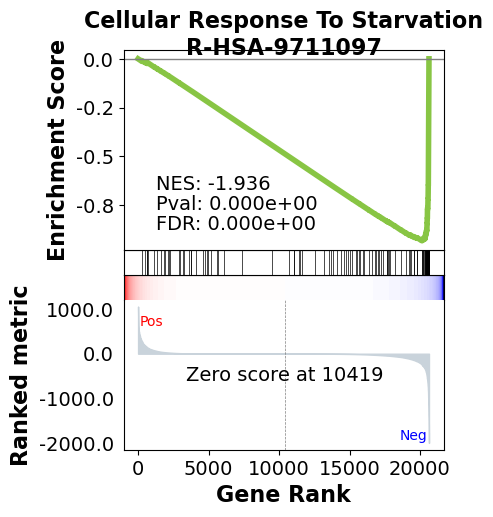

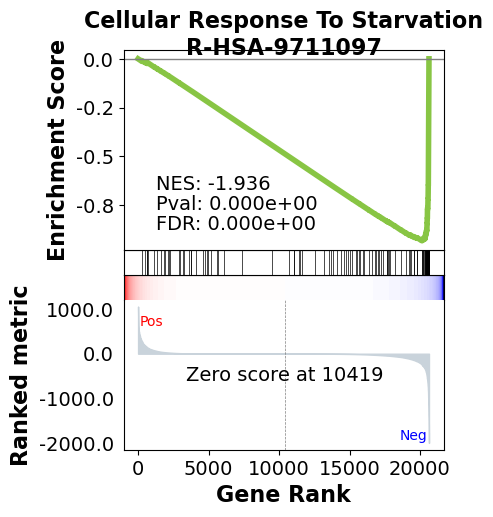

In [266]:
reactome_res.plot(terms="Cellular Response To Starvation R-HSA-9711097")


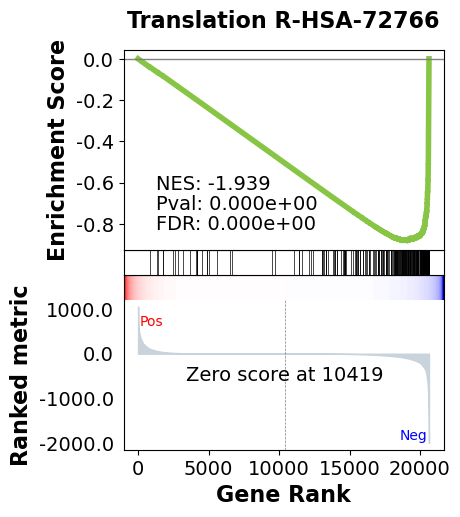

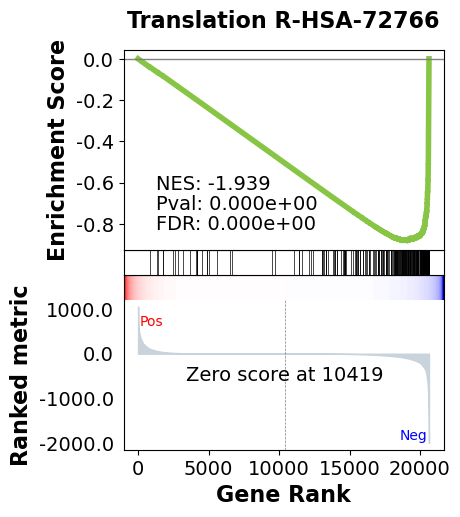

In [267]:
reactome_res.plot(terms="Translation R-HSA-72766")

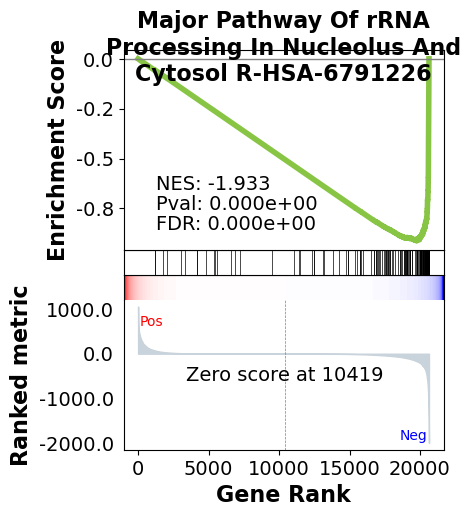

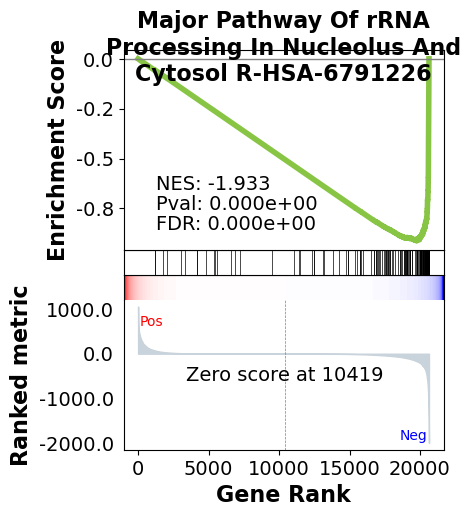

In [268]:
reactome_res.plot(terms="Major Pathway Of rRNA Processing In Nucleolus And Cytosol R-HSA-6791226")

In [269]:
reactome_df = reactome_res.res2d.sort_values("FDR q-val")
reactome_df.head(20)


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Translation R-HSA-72766,-0.881505,-1.938712,0.0,0.0,0.0,141/274,7.39%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
32,prerank,Nervous System Development R-HSA-9675108,-0.777199,-1.707595,0.0,0.0,0.0,92/482,4.42%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
31,prerank,Axon Guidance R-HSA-422475,-0.782520,-1.714588,0.0,0.0,0.0,92/459,4.42%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
28,prerank,mRNA Activation Upon Binding Of Cap-Binding Co...,-0.945499,-1.787336,0.0,0.0,0.0,35/57,2.55%,RPS12;RPS4X;RPSA;RPS8;RPS23;RPS19;RPS20;RPS5;R...
27,prerank,Translation Initiation Complex Formation R-HSA...,-0.948153,-1.787566,0.0,0.0,0.0,35/56,2.55%,RPS12;RPS4X;RPSA;RPS8;RPS23;RPS19;RPS20;RPS5;R...
26,prerank,"Formation Of Ternary Complex, And Subsequently...",-0.953762,-1.788651,0.0,0.0,0.0,35/49,2.55%,RPS12;RPS4X;RPSA;RPS8;RPS23;RPS19;RPS20;RPS5;R...
25,prerank,Ribosomal Scanning And Start Codon Recognition...,-0.944976,-1.803006,0.0,0.0,0.0,35/56,2.55%,RPS12;RPS4X;RPSA;RPS8;RPS23;RPS19;RPS20;RPS5;R...
24,prerank,Nuclear Events (Kinase And Transcription Facto...,0.781999,1.805094,0.0,0.0,0.0,20/55,8.05%,FOS;EP300;EGR1;CREB1;TRIB1;FOSB;EGR3;MAPK1;DNM...
22,prerank,Nonsense Mediated Decay (NMD) Independent Of E...,-0.965195,-1.825452,0.0,0.0,0.0,67/90,2.60%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
21,prerank,Peptide Chain Elongation R-HSA-156902,-0.970522,-1.841284,0.0,0.0,0.0,66/84,2.16%,RPL10A;RPS12;RPLP0;RPS4X;RPL4;RPL5;RPSA;RPS8;R...
